<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week4/Day3/Dailychallengesefi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Prédiction du cancer du sein

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import zipfile
import os

# 1. Sélectionner et téléverser le fichier ZIP
print("Veuillez choisir votre fichier ZIP (ex: archive (3) (1).zip) :")
uploaded = files.upload()

# Récupération du nom du fichier chargé
file_name = list(uploaded.keys())[0]
print(f"\nFichier détecté : {file_name}")

# Extraction automatique si c'est un fichier ZIP
if file_name.endswith('.zip'):
    print("Extraction du fichier ZIP en cours...")
    with zipfile.ZipFile(io.BytesIO(uploaded[file_name]), 'r') as zip_ref:
        zip_ref.extractall('extracted_data')

    # Recherche du fichier CSV extrait
    extracted_files = os.listdir('extracted_data')
    csv_files = [f for f in extracted_files if f.endswith('.csv')]

    if csv_files:
        csv_path = os.path.join('extracted_data', csv_files[0])
        print(f"Fichier CSV trouvé et sélectionné : {csv_path}")
        df = pd.read_csv(csv_path)
    else:
        raise FileNotFoundError("Aucun fichier CSV n'a été trouvé dans le ZIP.")
else:
    # Si vous téléversez directement un CSV
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Nettoyage de sécurité pour supprimer les espaces invisibles dans les colonnes
df.columns = df.columns.str.strip()

# 2. Examiner les premières lignes
print("\n--- Aperçu des 5 premières lignes ---")
print(df.head())

# 3. Vérifier les valeurs manquantes
print("\n--- Valeurs manquantes par colonne ---")
print(df.isnull().sum())

# Traiter les valeurs manquantes
df = df.dropna()

# 4. Supprimer la colonne d'identifiants inutiles si elle existe
if 'Patient_ID' in df.columns:
    df = df.drop(columns=['Patient_ID'])

# 5. Créer un graphique de comptage pour afficher le diagnostic (Patient_Status)
target_col = 'Patient_Status'

plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df, palette='magma')
plt.title("Distribution du diagnostic (Patient Status)")
plt.xlabel("Statut / Diagnostic")
plt.ylabel("Nombre de patients")
plt.show()


Veuillez choisir votre fichier ZIP (ex: archive (3) (1).zip) :


Saving archive (3).zip to archive (3) (2).zip

Fichier détecté : archive (3) (2).zip
Extraction du fichier ZIP en cours...
Fichier CSV trouvé et sélectionné : extracted_data/data.csv

--- Aperçu des 5 premières lignes ---
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.1279

ValueError: Could not interpret value `Patient_Status` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

Nombre de classes uniques : 2
Classes détectées : ['M' 'B']
Nombre total de lignes chargées : 569

             RÉSULTAT DE LA COMPARAISON FINALE
- Forêts Aléatoires         : 0.9737
- SVM                       : 0.9737
- Régression Logistique     : 0.9649
- KNN                       : 0.9561
------------------------------------------------------------
🏆 Le meilleur modèle est : Forêts Aléatoires avec 0.9737 d'accuracy


/tmp/ipykernel_474/3409010424.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_scores.values()), y=list(accuracy_scores.keys()), palette='viridis')


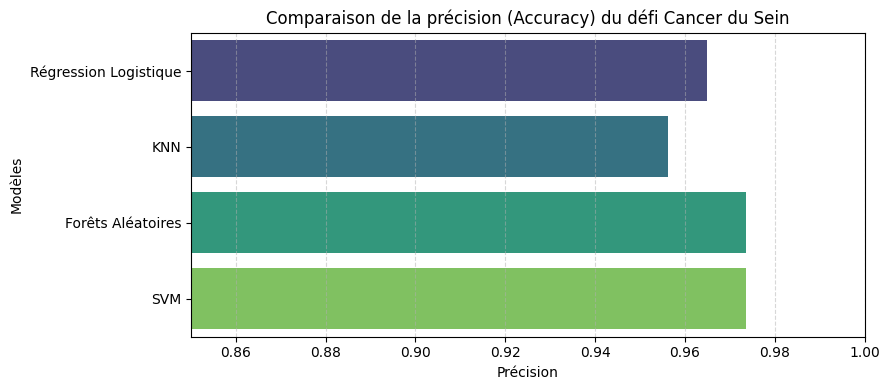

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# =====================================================================
# 1. CHARGEMENT ET RE-NETTOYAGE COMPLET DEPUIS LE DOSSIER EXTRACT
# =====================================================================
extracted_files = os.listdir('extracted_data')
csv_files = [f for f in extracted_files if f.endswith('.csv')]
csv_path = os.path.join('extracted_data', csv_files[0])

# Re-chargement propre du fichier d'origine pour écraser le DataFrame vide
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# Suppression immédiate de la colonne vide AVANT de faire le dropna
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Nettoyage des vraies lignes manquantes s'il y en a
df = df.dropna()

target_col = 'diagnosis'
print(f"Nombre de classes uniques : {df[target_col].nunique()}")
print(f"Classes détectées : {df[target_col].unique()}")
print(f"Nombre total de lignes chargées : {len(df)}")

# =====================================================================
# 2. PRÉTRAITEMENT DES DONNÉES
# =====================================================================
le_target = LabelEncoder()
y = le_target.fit_transform(df[target_col])
X = df.drop(columns=[target_col])

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# 3. ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES
# =====================================================================
accuracy_scores = {}

# Régression logistique
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)
accuracy_scores['Régression Logistique'] = accuracy_score(y_test, lr_model.predict(X_test_scaled))

# K plus proches voisins (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
accuracy_scores['KNN'] = accuracy_score(y_test, knn_model.predict(X_test_scaled))

# Forêts aléatoires
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
accuracy_scores['Forêts Aléatoires'] = accuracy_score(y_test, rf_model.predict(X_test))

# SVM
svm_model = SVC(kernel='rbf', random_state=RANDOM_STATE)
svm_model.fit(X_train_scaled, y_train)
accuracy_scores['SVM'] = accuracy_score(y_test, svm_model.predict(X_test_scaled))

# =====================================================================
# 4. COMPARAISON ET RAPPORT FINAL
# =====================================================================
best_model = max(accuracy_scores, key=accuracy_scores.get)

print("\n" + "="*60)
print("             RÉSULTAT DE LA COMPARAISON FINALE")
print("="*60)
for model, score in sorted(accuracy_scores.items(), key=lambda item: item[1], reverse=True):
    print(f"- {model:<25} : {score:.4f}")
print("-"*60)
print(f"🏆 Le meilleur modèle est : {best_model} avec {accuracy_scores[best_model]:.4f} d'accuracy")
print("="*60)

# Graphique récapitulatif
plt.figure(figsize=(9, 4))
sns.barplot(x=list(accuracy_scores.values()), y=list(accuracy_scores.keys()), palette='viridis')
plt.xlim(0.85, 1.0)
plt.title("Comparaison de la précision (Accuracy) du défi Cancer du Sein")
plt.xlabel("Précision")
plt.ylabel("Modèles")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
